# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abood-arc/Flyrank-ml-project/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [6]:
print("""I want to know which page is about to decline in search traffic next, before that
shows up in a normal monthly report. FlyRank already flags pages today using hand written
rules, a health score and some quick win tags. Those rules work and they run in production,
but they mostly describe a page's current state. I am asking a narrower question on top of
that. On the specific problem of decline, can a trained model beat that fixed rule, and how
much can I actually trust the answer once I check it properly.

The decision this supports is simple to say and hard to do well. Out of thousands of pages,
which one does a person look at first. If I get that wrong in one direction, nothing gets
reviewed until the drop is already old news. If I get it wrong the other way, a reviewer's
limited time goes to pages that were never really at risk. Both mistakes cost something real.

I made two framing choices early and held them the whole way through this project.

First, the label is client relative, not global. Decline rates in this data range from 0
percent to 93.7 percent across clients, so one fixed percent drop cutoff would flag almost
every page for an already struggling client and almost none for a thriving one. A page counts
as declining when its trend falls meaningfully below that client's own median trend, not
below some universal number.

Second, this predicts decline, it does not just describe it. FlyRank's existing flags score a
page's current state. I am asking the model to anticipate a page's near future state from data
that predates the outcome. That is a genuinely harder problem than scoring today's snapshot,
and it is also the more useful moment for a content team to actually step in.""")

I want to know which page is about to decline in search traffic next, before that
shows up in a normal monthly report. FlyRank already flags pages today using hand written
rules, a health score and some quick win tags. Those rules work and they run in production,
but they mostly describe a page's current state. I am asking a narrower question on top of
that. On the specific problem of decline, can a trained model beat that fixed rule, and how
much can I actually trust the answer once I check it properly.

The decision this supports is simple to say and hard to do well. Out of thousands of pages,
which one does a person look at first. If I get that wrong in one direction, nothing gets
reviewed until the drop is already old news. If I get it wrong the other way, a reviewer's
limited time goes to pages that were never really at risk. Both mistakes cost something real.

I made two framing choices early and held them the whole way through this project.

First, the label is client relative, 

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [16]:
print("""Every number in this notebook comes from FlyRank's internship warehouse on Hugging
Face. It is gated behind a free read token and pseudonymized before release, never a live
client feed. I use fact_content_daily_performance, one row per content item, per client, per
report date, joined to dim_content for static attributes like content type. This analysis
spans March 1 through June 30, 2026. March and April are my feature window, May into June is
my label window.

I left some things out on purpose. dim_content is a single export time snapshot, not a per
day history, so mutable fields like last_optimized_date, optimization_eligible_date,
is_deleted and is_published do not mean what they would look like they mean at any given
report date. I dropped provider_used, model_used, backlinks and category_count too, because
nothing documents what they actually are, and I do not use a column I cannot explain. Product
flags like the health score are outputs of a decision FlyRank's product already made, so I
only use them as the thing I am comparing against, never as something the model gets to see.
Any page missing GSC data in one of the four months, sitting under a 50 impression floor in
May, or belonging to a client with fewer than 20 eligible items, gets excluded from the
eligible population entirely. It does not get defaulted to not declining, it simply is not
eligible to have an opinion about.

Coverage is not even across the panel either. GSC data is present for about 36.7 percent of
raw rows. GA4 is present for only about 4 to 5.5 percent, depending on the month. That is real
evidence for a thin slice of pages, so I never treat a GA4 based feature as equal in weight to
a GSC one.

client_hash_id and content_hash_id are one way pseudonymous hashes. I use them only for
grouping, labeling and splitting, never as a model feature. No client name, domain, or raw
query shows up anywhere in this analysis.""")

Every number in this notebook comes from FlyRank's internship warehouse on Hugging
Face. It is gated behind a free read token and pseudonymized before release, never a live
client feed. I use fact_content_daily_performance, one row per content item, per client, per
report date, joined to dim_content for static attributes like content type. This analysis
spans March 1 through June 30, 2026. March and April are my feature window, May into June is
my label window.

I left some things out on purpose. dim_content is a single export time snapshot, not a per
day history, so mutable fields like last_optimized_date, optimization_eligible_date,
is_deleted and is_published do not mean what they would look like they mean at any given
report date. I dropped provider_used, model_used, backlinks and category_count too, because
nothing documents what they actually are, and I do not use a column I cannot explain. Product
flags like the health score are outputs of a decision FlyRank's product already ma

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [8]:
import os
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

import duckdb, pandas as pd, numpy as np

con = duckdb.connect()
con.execute("SET enable_progress_bar=false")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{os.environ['HF_TOKEN']}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'

def month_read(m):
    return f"""
    SELECT content_hash_id, client_hash_id, report_date, gsc_data_available,
           gsc_impressions, gsc_clicks, gsc_avg_position, ga4_data_available, ga4_engaged_sessions
    FROM read_parquet('{REL}/fact_content_daily_performance/month={m}/*.parquet')
    """
months = ["2026-03", "2026-04", "2026-05", "2026-06"]
union_sql = " UNION ALL ".join(f"({month_read(m)})" for m in months)

raw = con.sql(f"""
    WITH unioned AS ({union_sql})
    SELECT
        f.content_hash_id,
        ANY_VALUE(f.client_hash_id) AS client_hash_id,
        MAX(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' THEN gsc_data_available::INT END) AS has_gsc_mar,
        MAX(CASE WHEN report_date >= DATE '2026-04-01' AND report_date < DATE '2026-05-01' THEN gsc_data_available::INT END) AS has_gsc_apr,
        MAX(CASE WHEN report_date >= DATE '2026-05-01' AND report_date < DATE '2026-06-01' THEN gsc_data_available::INT END) AS has_gsc_may,
        MAX(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' THEN gsc_data_available::INT END) AS has_gsc_jun,
        MAX(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' THEN ga4_data_available::INT END) AS has_ga4_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_mar,
        SUM(CASE WHEN report_date >= DATE '2026-04-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_apr,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE THEN gsc_clicks ELSE 0 END) AS clicks_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_avg_position * gsc_impressions ELSE 0 END) AS pos_wsum_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_impressions ELSE 0 END) AS pos_wden_feat,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01' AND ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE 0 END) AS ga4_engaged_feat,
        SUM(CASE WHEN report_date >= DATE '2026-05-01' AND report_date < DATE '2026-06-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_may,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE THEN gsc_impressions ELSE 0 END) AS impr_jun,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE THEN gsc_clicks ELSE 0 END) AS clicks_jun,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_avg_position * gsc_impressions ELSE 0 END) AS pos_wsum_jun,
        SUM(CASE WHEN report_date >= DATE '2026-06-01' AND report_date < DATE '2026-07-01' AND gsc_data_available IS TRUE AND gsc_avg_position > 0 THEN gsc_impressions ELSE 0 END) AS pos_wden_jun
    FROM unioned f GROUP BY f.content_hash_id
""").df()
dim_content = con.sql(f"SELECT content_hash_id, content_type, content_updated_date FROM {DIM_CONTENT}").df()
df = raw.merge(dim_content, on="content_hash_id", how="left")
df = df.sort_values("content_hash_id").reset_index(drop=True)
df["pos_feat"] = np.where(df["pos_wden_feat"] > 0, df["pos_wsum_feat"] / df["pos_wden_feat"], np.nan)
df["pos_jun"] = np.where(df["pos_wden_jun"] > 0, df["pos_wsum_jun"] / df["pos_wden_jun"], np.nan)
df["impr_feat"] = df["impr_mar"] + df["impr_apr"]

print("""I need two eligibility chains to both hold at once, not just one. Mine needs real
feature and label data plus enough May volume to trust a trend. The baseline's needs at least
100 June impressions, a valid position, and 30 days since the page was last touched, so a
recent edit does not get judged before it had time to show anything. Intersecting both first
and only applying the client floor last matters here. Applying the floor before intersecting
overcounted clients earlier in this project, so I hold that order on purpose.""")

VOL_FLOOR_MAY, VOL_FLOOR_JUN_BASELINE = 50, 100
model_elig = ((df["has_gsc_mar"]==1)&(df["has_gsc_apr"]==1)&(df["has_gsc_may"]==1)&(df["has_gsc_jun"]==1)
              & (df["impr_may"] >= VOL_FLOOR_MAY) & df["pos_feat"].notna())
df["staleness_days"] = (pd.Timestamp("2026-06-30") - pd.to_datetime(df["content_updated_date"])).dt.days
baseline_elig = ((df["impr_jun"] >= VOL_FLOOR_JUN_BASELINE) & df["pos_jun"].notna() & (df["staleness_days"] >= 30))

shared = df[model_elig & baseline_elig].copy()
client_counts = shared.groupby("client_hash_id")["content_hash_id"].transform("count")
shared = shared[client_counts >= 20].copy()

shared["trend_pct"] = (shared["impr_jun"] - shared["impr_may"]) / shared["impr_may"] * 100
client_med = shared.groupby("client_hash_id")["trend_pct"].transform("median")
shared["relative_gap"] = shared["trend_pct"] - client_med
THRESHOLD = shared["relative_gap"].quantile(0.25)
shared["is_declining"] = (shared["relative_gap"] < THRESHOLD).astype(int)

print(f"""Shared population: {len(shared):,} items across {shared['client_hash_id'].nunique()}
clients. That is smaller than either eligibility chain alone, and that is the honest cost of a
fair comparison, not a mistake. relative_gap is a page's May into June trend minus that
client's own median trend over the same window. A page counts as declining when relative_gap
falls below the 25th percentile break of this population's own distribution, which lands at
{THRESHOLD:.2f} here. Base rate: {shared['is_declining'].mean():.3f}.""")

shared["within_window_trend"] = np.where(shared["impr_mar"]>0, (shared["impr_apr"]-shared["impr_mar"])/shared["impr_mar"]*100, np.nan).clip(-1e6,1e6)
shared["within_window_trend"] = shared["within_window_trend"].fillna(0)
shared["ctr_feat"] = np.where(shared["impr_feat"]>0, shared["clicks_feat"]/shared["impr_feat"], 0)
shared["ga4_engaged_feat"] = shared["ga4_engaged_feat"].fillna(0)
shared["has_ga4_feat"] = shared["has_ga4_feat"].fillna(0).astype(int)
client_total_feat = shared.groupby("client_hash_id")["impr_feat"].transform("sum")
shared["feat_client_share"] = shared["impr_feat"] / client_total_feat
shared = pd.get_dummies(shared, columns=["content_type"], dummy_na=True, prefix="content_type")
feature_cols = (["impr_feat","clicks_feat","pos_feat","ga4_engaged_feat","has_ga4_feat",
                  "ctr_feat","within_window_trend","feat_client_share"]
                + [c for c in shared.columns if c.startswith("content_type_")])

def position_bucket(p):
    if p<=3: return "1_pos_1-3"
    if p<=6: return "2_pos_4-6"
    if p<=10: return "3_pos_7-10"
    if p<=20: return "4_pos_11-20"
    return "5_pos_21plus"
shared["position_bucket"] = shared["pos_jun"].apply(position_bucket)
shared["item_ctr_pct"] = shared["clicks_jun"]*100/shared["impr_jun"]
expected_by_bucket = shared.groupby("position_bucket").apply(lambda g: g["clicks_jun"].sum()*100/g["impr_jun"].sum(), include_groups=False)
shared["expected_ctr_pct"] = shared["position_bucket"].map(expected_by_bucket)
shared["ctr_gap_pct"] = shared["expected_ctr_pct"] - shared["item_ctr_pct"]
client_totals_jun = shared.groupby("client_hash_id")["impr_jun"].transform("sum")
shared["client_traffic_share"] = shared["impr_jun"] / client_totals_jun
shared["baseline_score"] = shared["ctr_gap_pct"].clip(lower=0) * shared["client_traffic_share"]

print(f"""My feature set has {len(feature_cols)} columns. Five come from the data contract I
already locked in an earlier notebook: impressions, clicks, position, GA4 engaged sessions,
and content type. Two more earned their place through testing rather than by default.
within_window_trend compares March to April inside the feature window, so it never touches
label data, and it is my only early hint that a page was already sliding. feat_client_share is
this page's share of its own client's feature window traffic, and I only added it after
finding why my baseline underperforms, which I show below. I also tried a client relative
version of position once. It made every metric worse, so I left it out.

My baseline is a transparent rule, built first, with no decline label anywhere near it. It
compares each page's actual click through rate against the expected rate for its position
tier, floors that gap at zero, and multiplies it by the page's share of its own client's
traffic. I tried staleness as a signal too, but the active population here is almost never the
stale content, so an age based rule would have nothing real to catch. I also tried firing on
any positive click through gap, but that is true for about 60 percent of pages, which is not a
flag, it is almost everyone. Firing on the top quartile of the gap score is what I use here.""")


I need two eligibility chains to both hold at once, not just one. Mine needs real
feature and label data plus enough May volume to trust a trend. The baseline's needs at least
100 June impressions, a valid position, and 30 days since the page was last touched, so a
recent edit does not get judged before it had time to show anything. Intersecting both first
and only applying the client floor last matters here. Applying the floor before intersecting
overcounted clients earlier in this project, so I hold that order on purpose.
Shared population: 34,668 items across 25
clients. That is smaller than either eligibility chain alone, and that is the honest cost of a
fair comparison, not a mistake. relative_gap is a page's May into June trend minus that
client's own median trend over the same window. A page counts as declining when relative_gap
falls below the 25th percentile break of this population's own distribution, which lands at
-20.82 here. Base rate: 0.250.
My feature set has 12 columns

In [9]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

X_all = shared[feature_cols].fillna(0)
y_all = shared["is_declining"]
groups_all = shared["client_hash_id"]

def precision_at_k(scores, labels, tiebreak, k):
    order = np.lexsort((-tiebreak, -scores))
    return labels.values[order[:k]].mean()

print("""Every comparison in this notebook is averaged over 20 client grouped splits, never a
random row level split. With only 25 clients feeding this population, a random split lets the
model partly memorize which client a page belongs to, and that inflates the score in a way
that will not hold on a client the model has never seen. I check exactly how large that
honesty gap is below, measured, not assumed.

Before trusting any of it, I run the same leakage attack I have used since the very start of
this project on the final 12 feature set. I hand the model a feature it should never get and
watch the score break.""")

def score_featureset(cols, seed=7):
    X = shared[cols].fillna(0)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_idx, te_idx = next(gss.split(X, y_all, groups_all))
    rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42, n_jobs=-1).fit(X.iloc[tr_idx], y_all.iloc[tr_idx])
    tb = shared["impr_feat"].iloc[te_idx].values
    yt = y_all.iloc[te_idx].values
    return precision_at_k(pd.Series(rf.predict_proba(X.iloc[te_idx])[:,1]), pd.Series(yt), tb, 50)

honest = score_featureset(feature_cols)
with_label_leak = score_featureset(feature_cols + ["relative_gap"])
with_future_leak = score_featureset(feature_cols + ["impr_jun"])

print(f"""honest 12 feature set: Precision at 50 is {honest:.3f}
adding relative_gap, the exact number is_declining is thresholded from: {with_label_leak:.3f}
adding impr_jun, a future window number with no formula tie to the label: {with_future_leak:.3f}

Handing the model relative_gap hands it the answer key, so that score saturates. impr_jun has
no arithmetic relationship to the label at all and it still nearly doubles the honest score, so
a leak does not need to share the label's formula to be fatal. All 12 shipped features are
March and April only by construction. Five are summed only over the feature window in the SQL
that builds them. within_window_trend compares March to April and never touches May or June.
feat_client_share uses feature window traffic only. content_type is a static attribute with no
time dimension to leak through. None of these are product flags or existing FlyRank scores
either, so I trust this feature set going into the results below.""")


Every comparison in this notebook is averaged over 20 client grouped splits, never a
random row level split. With only 25 clients feeding this population, a random split lets the
model partly memorize which client a page belongs to, and that inflates the score in a way
that will not hold on a client the model has never seen. I check exactly how large that
honesty gap is below, measured, not assumed.

Before trusting any of it, I run the same leakage attack I have used since the very start of
this project on the final 12 feature set. I hand the model a feature it should never get and
watch the score break.
honest 12 feature set: Precision at 50 is 0.440
adding relative_gap, the exact number is_declining is thresholded from: 1.000
adding impr_jun, a future window number with no formula tie to the label: 0.720

Handing the model relative_gap hands it the answer key, so that score saturates. impr_jun has
no arithmetic relationship to the label at all and it still nearly doubles the honest 

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [10]:
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def run_one(seed, grouped):
    if grouped:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
        tr_idx, te_idx = next(splitter.split(X_all, y_all, groups_all))
    else:
        splitter = ShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
        tr_idx, te_idx = next(splitter.split(X_all, y_all))
    X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
    y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]

    logreg = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)).fit(X_tr, y_tr)
    rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    n_pos, n_neg = y_tr.sum(), len(y_tr) - y_tr.sum()
    sw = np.where(y_tr == 1, len(y_tr) / (2 * n_pos), len(y_tr) / (2 * n_neg))
    gbm = HistGradientBoostingClassifier(max_depth=6, max_iter=200, random_state=42).fit(X_tr, y_tr, sample_weight=sw)

    tb, yt = shared["impr_feat"].iloc[te_idx].values, y_te.values
    return {
        "baseline_p50": precision_at_k(shared["baseline_score"].iloc[te_idx].fillna(0), pd.Series(yt), tb, 50),
        "logreg_p50": precision_at_k(pd.Series(logreg.predict_proba(X_te)[:,1]), pd.Series(yt), tb, 50),
        "rf_p50": precision_at_k(pd.Series(rf.predict_proba(X_te)[:,1]), pd.Series(yt), tb, 50),
        "gbm_p50": precision_at_k(pd.Series(gbm.predict_proba(X_te)[:,1]), pd.Series(yt), tb, 50),
        "baseline_p20": precision_at_k(shared["baseline_score"].iloc[te_idx].fillna(0), pd.Series(yt), tb, 20),
        "logreg_p20": precision_at_k(pd.Series(logreg.predict_proba(X_te)[:,1]), pd.Series(yt), tb, 20),
        "rf_p20": precision_at_k(pd.Series(rf.predict_proba(X_te)[:,1]), pd.Series(yt), tb, 20),
        "gbm_p20": precision_at_k(pd.Series(gbm.predict_proba(X_te)[:,1]), pd.Series(yt), tb, 20),
    }

print("Running 20 client grouped splits and 20 random splits for four methods. This is the slow cell.")
grouped_res = pd.DataFrame([run_one(s, grouped=True) for s in range(20)])
random_res = pd.DataFrame([run_one(s, grouped=False) for s in range(20)])

print(f"\nbase rate: {y_all.mean():.3f}   population: {len(shared):,} items across {shared['client_hash_id'].nunique()} clients\n")
for name in ["baseline","logreg","rf","gbm"]:
    p50, p20 = grouped_res[f"{name}_p50"], grouped_res[f"{name}_p20"]
    print(f"{name:<10} grouped P@50 {p50.mean():.3f} (range {p50.min():.3f} to {p50.max():.3f})   grouped P@20 {p20.mean():.3f} (range {p20.min():.3f} to {p20.max():.3f})")

print("""
The baseline sits below the base rate. Random Forest comes out on top of the three trained
methods. Gradient Boosting loses to Random Forest here despite more flexibility, and I show
why that is not a fluke in the next cell. I want to be precise about what beating the baseline
means. The baseline rule was never built to predict decline, it deliberately has no forward
looking label anywhere in it, by design, from the week I built it. So this is a dedicated
predictor beating a repurposed heuristic, not proof that the baseline is broken at its own
job. The next cell explains why the repurposing specifically fails, not just that it does.""")

print("=== why the baseline underperforms its own base rate ===")
print(f"correlation of ctr_gap_pct with is_declining: {shared['ctr_gap_pct'].corr(shared['is_declining']):.4f}")
print(f"correlation of client_traffic_share with is_declining: {shared['client_traffic_share'].corr(shared['is_declining']):.4f}")
top50b = shared.sort_values("baseline_score", ascending=False).head(50)
print(f"decline rate in the baseline's own top 50: {top50b['is_declining'].mean():.3f} against a base rate of {shared['is_declining'].mean():.3f}")
print(f"mean client_traffic_share there: {top50b['client_traffic_share'].mean():.4f} against a population average of {shared['client_traffic_share'].mean():.4f}")

print("""
The click through gap term is mildly useful on its own. The problem is client_traffic_share,
the term I added specifically to stop the score rewarding raw traffic volume. It has a clean
inverse relationship with decline, so multiplying the two together systematically boosts high
share pages, the stable, established ones least likely to be the ones about to decline. This
is not a bug in the rule. It was a reasonable design choice for the rule's original job of
surfacing current underperformance, and it works against a job it was never asked to do until
I asked it to here.""")


Running 20 client grouped splits and 20 random splits for four methods. This is the slow cell.

base rate: 0.250   population: 34,668 items across 25 clients

baseline   grouped P@50 0.135 (range 0.060 to 0.240)   grouped P@20 0.105 (range 0.000 to 0.250)
logreg     grouped P@50 0.381 (range 0.220 to 0.680)   grouped P@20 0.313 (range 0.150 to 0.650)
rf         grouped P@50 0.455 (range 0.220 to 0.600)   grouped P@20 0.452 (range 0.150 to 0.650)
gbm        grouped P@50 0.382 (range 0.220 to 0.600)   grouped P@20 0.382 (range 0.100 to 0.650)

The baseline sits below the base rate. Random Forest comes out on top of the three trained
methods. Gradient Boosting loses to Random Forest here despite more flexibility, and I show
why that is not a fluke in the next cell. I want to be precise about what beating the baseline
means. The baseline rule was never built to predict decline, it deliberately has no forward
looking label anywhere in it, by design, from the week I built it. So this is a de

Here is the same comparison under a plain random split that ignores which client a
page belongs to, the split most people reach for by default.

baseline random P@50 0.149   grouped P@50 0.135
logreg   random P@50 0.410   grouped P@50 0.381
rf       random P@50 0.561   grouped P@50 0.455
gbm      random P@50 0.590   grouped P@50 0.382

The untrained baseline barely moves, which is exactly what an honest control should do. Random
Forest moves some, a gap of 0.106. Gradient Boosting moves the most, a gap of
0.208, enough that its ranking against Random Forest flips. Gradient Boosting beats
Random Forest in 13 of 20 random split seeds. Random Forest beats Gradient
Boosting in 14 of 20 grouped split seeds. Under the split most people would
reach for first, I would have shipped the wrong model. This is why I use Random Forest and not
Gradient Boosting going forward. It is not that Gradient Boosting lost once, it lost
consistently on every honest check, and it is more sensitive to split choi

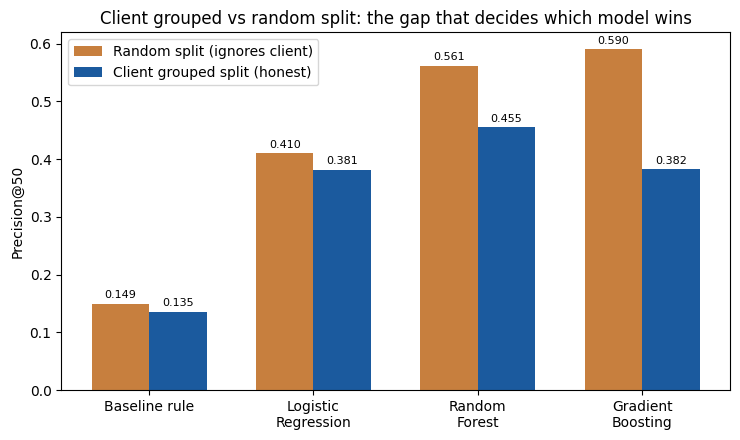

In [11]:
import matplotlib.pyplot as plt

gbm_wins_random = int((random_res["gbm_p50"] > random_res["rf_p50"]).sum())
rf_wins_grouped = int((grouped_res["rf_p50"] > grouped_res["gbm_p50"]).sum())
gap_rf = random_res["rf_p50"].mean() - grouped_res["rf_p50"].mean()
gap_gbm = random_res["gbm_p50"].mean() - grouped_res["gbm_p50"].mean()

print(f"""Here is the same comparison under a plain random split that ignores which client a
page belongs to, the split most people reach for by default.

baseline random P@50 {random_res['baseline_p50'].mean():.3f}   grouped P@50 {grouped_res['baseline_p50'].mean():.3f}
logreg   random P@50 {random_res['logreg_p50'].mean():.3f}   grouped P@50 {grouped_res['logreg_p50'].mean():.3f}
rf       random P@50 {random_res['rf_p50'].mean():.3f}   grouped P@50 {grouped_res['rf_p50'].mean():.3f}
gbm      random P@50 {random_res['gbm_p50'].mean():.3f}   grouped P@50 {grouped_res['gbm_p50'].mean():.3f}

The untrained baseline barely moves, which is exactly what an honest control should do. Random
Forest moves some, a gap of {gap_rf:.3f}. Gradient Boosting moves the most, a gap of
{gap_gbm:.3f}, enough that its ranking against Random Forest flips. Gradient Boosting beats
Random Forest in {gbm_wins_random} of 20 random split seeds. Random Forest beats Gradient
Boosting in {rf_wins_grouped} of 20 grouped split seeds. Under the split most people would
reach for first, I would have shipped the wrong model. This is why I use Random Forest and not
Gradient Boosting going forward. It is not that Gradient Boosting lost once, it lost
consistently on every honest check, and it is more sensitive to split choice, not less.""")

models = ["baseline","logreg","rf","gbm"]
labels_ = ["Baseline rule","Logistic\nRegression","Random\nForest","Gradient\nBoosting"]
random_means = [random_res[f"{m}_p50"].mean() for m in models]
grouped_means = [grouped_res[f"{m}_p50"].mean() for m in models]

fig, ax = plt.subplots(figsize=(7.5,4.5))
x = np.arange(len(models)); w = 0.35
b1 = ax.bar(x - w/2, random_means, w, label="Random split (ignores client)", color="#c77f3e")
b2 = ax.bar(x + w/2, grouped_means, w, label="Client grouped split (honest)", color="#1b5a9e")
ax.set_xticks(x); ax.set_xticklabels(labels_)
ax.set_ylabel("Precision@50")
ax.set_title("Client grouped vs random split: the gap that decides which model wins")
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


## 5. Limitations

*What this work cannot claim.*

In [12]:
print("""Here is what this work cannot claim, stated before anyone else has to go find it.

This is not forecasting a page's own trajectory. Earlier in this project I ran a persistence
check five different ways, a 30 day trend ratio, a 60 day trend ratio, a regression slope, a
position based version, and a declining twice in a row version. All five came back close to a
coin flip. A page's own recent trend does not meaningfully predict its own near future trend,
at any window or method I tried. What the model actually predicts is narrower than that. It
asks whether other properties of a page, an early within window slide, its share of its own
client's traffic, position, clicks, associate with this specific label. That turned out to be
answerable even though the bigger, more ambitious question was not.

There is an open sign flip I have not resolved. feat_client_share, built from March and April,
predicts decline in the positive direction, low share goes with less decline. The baseline's
own client_traffic_share, built from June, predicts it in the negative direction. A mean
reversion story is plausible here, a page with an unusually high recent share may partly
reflect a temporary spike that naturally settles back down, but I have not tested that, so I
am naming it rather than quietly carrying it forward.

Split sensitivity itself is only partly understood. I showed above that Gradient Boosting is
measurably more vulnerable to an ungrouped split than Random Forest, and I reproduced that more
than once. Why it is more vulnerable is not tested. More flexibility giving it more room to fit
client specific noise is a reasonable guess, not a confirmed answer.

This is a historical fold demonstration, not a live production run. The action queue below is
scored against May into June 2026, a period where I already know the outcome. Standing this up
against a real current month means pulling a fresh feature window and scoring items with no
known outcome yet, which is a real next step I have not done here.

New items are excluded by inference, not by a direct check. This schema has no content creation
date, only an edit history field. Requiring real GSC data across all four months rules out
anything that only recently started appearing, but I cannot confirm that against an actual
creation timestamp because the field does not exist.

This is a small, specific population. Roughly 34 thousand items across 25 clients is the
honest cost of a fair, doubly eligible comparison, smaller than either eligibility chain on
its own. These results describe this cohort and this label design. They are not a claim about
generalizing to a different month, a different client mix, or a different definition of
decline.

Nothing here is a causal claim. Nothing establishes that any feature causes decline, and
nothing claims to model or predict a Google ranking algorithm. Every number in this notebook
is observed, measured, directional, and meant for decision support, never causal.""")


Here is what this work cannot claim, stated before anyone else has to go find it.

This is not forecasting a page's own trajectory. Earlier in this project I ran a persistence
check five different ways, a 30 day trend ratio, a 60 day trend ratio, a regression slope, a
position based version, and a declining twice in a row version. All five came back close to a
coin flip. A page's own recent trend does not meaningfully predict its own near future trend,
at any window or method I tried. What the model actually predicts is narrower than that. It
asks whether other properties of a page, an early within window slide, its share of its own
client's traffic, position, clicks, associate with this specific label. That turned out to be
answerable even though the bigger, more ambitious question was not.

There is an open sign flip I have not resolved. feat_client_share, built from March and April,
predicts decline in the positive direction, low share goes with less decline. The baseline's
own clie

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [13]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=7)
tr_idx, te_idx = next(gss.split(X_all, y_all, groups_all))
rf_final = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42, n_jobs=1).fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
te_df = shared.iloc[te_idx].copy()
te_df["rf_proba"] = rf_final.predict_proba(X_all.iloc[te_idx])[:,1]

GAP_Q75 = shared["ctr_gap_pct"].quantile(0.75)
te_df["rule_fires"] = te_df["ctr_gap_pct"] >= GAP_Q75
VERIFY_THRESHOLD = 700
REVIEW_K = 100

order = np.lexsort((-te_df["impr_feat"].values, -te_df["rf_proba"].values))
ranked = te_df.iloc[order].reset_index(drop=True)
ranked["rank"] = ranked.index + 1
ranked["verify_first"] = ranked["within_window_trend"].abs() >= VERIFY_THRESHOLD
ranked["expected_click_lift"] = (ranked["ctr_gap_pct"].clip(lower=0) / 100) * ranked["impr_feat"]

def band_of(row):
    if row["rank"] <= REVIEW_K:
        return "review_before_revert" if row["rule_fires"] else "investigate_quiet_risk"
    return "monitor_only" if row["trend_pct"] > 0 else "not_flagged"
ranked["band"] = ranked.apply(band_of, axis=1)
band_counts = ranked["band"].value_counts()
top100 = ranked.head(100)

print(f"""The model's score alone is not a queue. I fuse priority, the model's probability,
with reason, whether the transparent rule agrees, into four bands.

On this holdout fold of {len(te_df):,} items across {te_df['client_hash_id'].nunique()}
clients, only {band_counts.get('review_before_revert',0) + band_counts.get('investigate_quiet_risk',0)}
items actually get a do something this week action. That is the real size of a week's work
here, not the eligible population.

review_before_revert, rule and model agree: {band_counts.get('review_before_revert',0)} items.
This still needs a person to inspect the page and form a hypothesis before anyone reverts or
edits anything.

investigate_quiet_risk, the model flags it but the rule does not corroborate:
{band_counts.get('investigate_quiet_risk',0)} items. This one is mandatory review, not
optional, because there is no independent reason backing it up yet on its own.

monitor_only, a positive trend, watched but not acted on: {band_counts.get('monitor_only',0):,}
items. Acting on a recent positive trend risks manufacturing a false win out of noise, and I
already showed above that a page's own trend does not reliably persist.

not_flagged, no signal this period: {band_counts.get('not_flagged',0):,} items.

Inside the top 100, {int(top100['verify_first'].sum())} items swing more than
{VERIFY_THRESHOLD} percent between March and April. I checked whether that swing predicts
which ones are false alarms. It does not, the decline rate above and below that threshold is
close enough to call the same. So this is not a true or false positive filter, it is a
sequencing rule. Verify the number is real before treating it as a content problem, whichever
way it turns out. Most of these come from a small March baseline inflating a normal April
number into a huge percentage, the same mechanism an earlier notebook in this project already
caught.

Priority order and value order point in different directions too. The model's probability
ranks who to look at first. It does not rank what is worth the most if a reviewer only gets
through part of the queue. Both orderings are worth keeping side by side, since which one
matters depends on whether today's constraint is time or impact.""")


The model's score alone is not a queue. I fuse priority, the model's probability,
with reason, whether the transparent rule agrees, into four bands.

On this holdout fold of 20,292 items across 7
clients, only 100
items actually get a do something this week action. That is the real size of a week's work
here, not the eligible population.

review_before_revert, rule and model agree: 32 items.
This still needs a person to inspect the page and form a hypothesis before anyone reverts or
edits anything.

investigate_quiet_risk, the model flags it but the rule does not corroborate:
68 items. This one is mandatory review, not
optional, because there is no independent reason backing it up yet on its own.

monitor_only, a positive trend, watched but not acted on: 4,689
items. Acting on a recent positive trend risks manufacturing a false win out of noise, and I
already showed above that a page's own trend does not reliably persist.

not_flagged, no signal this period: 15,503 items.

Inside the t

In [14]:
top_client = top100["client_hash_id"].value_counts().index[0]
top_client_n = top100["client_hash_id"].value_counts().iloc[0]
pop_share = (ranked["client_hash_id"]==top_client).mean()

print(f"""One more check before trusting this as {len(top100)} independent findings. One
client holds {top_client_n} of the top 100 items, against only {pop_share:.1%} of the
eligible population in this fold. Before treating that client's rows as separate problems,
someone should look at that client's pages by hand first.

Some things should never be automated off this list, so I am writing them down plainly.
No content edit or revert gets applied automatically. Every action here ends at a human
decision. No per client retraining or per client thresholds, one pooled model on purpose,
held since the label was first designed. No swapping Gradient Boosting in for convenience
without re running the split sensitivity check above. No treating an investigate_quiet_risk
flag as a validated finding on its own, it is a lead to check, not a conclusion. No running
this queue against a live current month without rebuilding the feature window and
re validating first, this fold is a historical demonstration, not a production feed.

Monitoring needs a concrete trigger, not a vague promise to check in sometime. Before this
ever ships to a reviewer, I compare the live population size and client count against what I
validated here, {len(shared):,} items and {shared['client_hash_id'].nunique()} clients, and
flag anything that drifts more than 15 percent. Once a real next period's outcome is known, I
compare its actual decline rate against the {shared['is_declining'].mean():.3f} base rate this
model trained on, and a shift bigger than 5 points means the population has changed enough
that the old training data may not describe it anymore. If the model underperforms the frozen
baseline rule for two straight monitoring periods, I fall back to the rule until the model is
re validated. That gives when do I stop trusting this a testable answer instead of a judgment
call made under pressure. I would retrain if the client roster shifts materially, if the
feature schema changes upstream, or after two straight monitoring misses.

One known gap I am naming rather than quietly handling. Recently optimized pages need a
deployment time join against whatever FlyRank's product already acted on, so this queue does
not re flag something already being fixed. That is proposed here, not built.""")


One more check before trusting this as 100 independent findings. One
client holds 45 of the top 100 items, against only 3.7% of the
eligible population in this fold. Before treating that client's rows as separate problems,
someone should look at that client's pages by hand first.

Some things should never be automated off this list, so I am writing them down plainly.
No content edit or revert gets applied automatically. Every action here ends at a human
decision. No per client retraining or per client thresholds, one pooled model on purpose,
held since the label was first designed. No swapping Gradient Boosting in for convenience
without re running the split sensitivity check above. No treating an investigate_quiet_risk
flag as a validated finding on its own, it is a lead to check, not a conclusion. No running
this queue against a live current month without rebuilding the feature window and
re validating first, this fold is a historical demonstration, not a production feed.

Monitoring

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

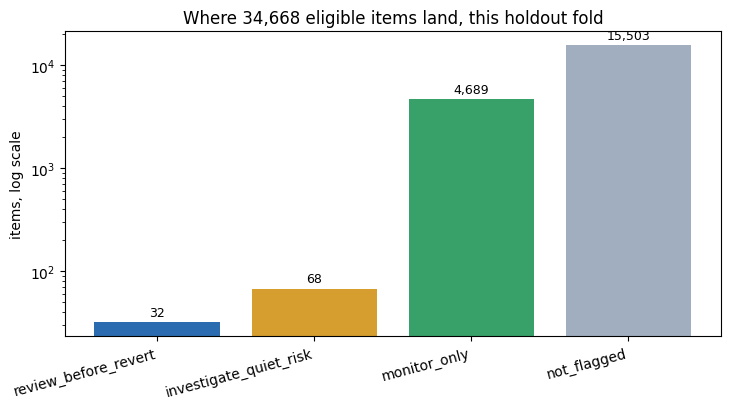

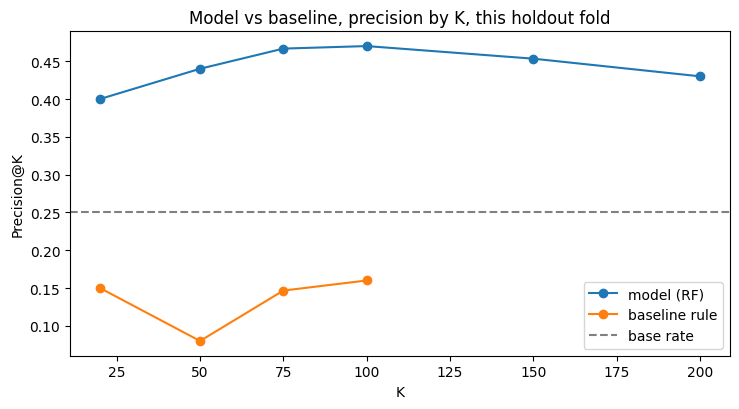

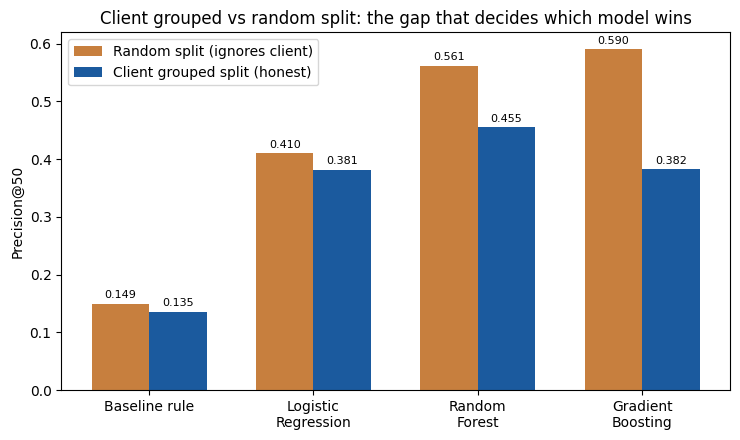

Saved work/outputs/action_queue.csv with 20,292 ranked rows, three charts
in work/figures, and a metrics file the deployed paper reads its numbers from. Everything on
that page traces back to a cell in this notebook that actually ran, not a number I remembered
or copied from an earlier session.


In [15]:
import pathlib, json

pathlib.Path("work/outputs").mkdir(parents=True, exist_ok=True)
pathlib.Path("work/figures").mkdir(parents=True, exist_ok=True)

pk = {k: precision_at_k(pd.Series(te_df["rf_proba"].values), pd.Series(te_df["is_declining"].values), te_df["impr_feat"].values, k) for k in [20,50,75,100,150,200]}
baseline_pk = {k: precision_at_k(pd.Series(te_df["baseline_score"].fillna(0).values), pd.Series(te_df["is_declining"].values), te_df["impr_feat"].values, k) for k in [20,50,75,100]}

output_cols = ["rank","content_hash_id","client_hash_id","rf_proba","is_declining","relative_gap",
               "band","verify_first","expected_click_lift","ctr_gap_pct","within_window_trend",
               "impr_feat","pos_feat","feat_client_share","trend_pct"]
ranked[output_cols].to_csv("work/outputs/action_queue.csv", index=False)

fig, ax = plt.subplots(figsize=(7.5,4.2))
band_order = ["review_before_revert","investigate_quiet_risk","monitor_only","not_flagged"]
counts = band_counts.reindex(band_order, fill_value=0)
bars = ax.bar(range(len(counts)), counts.values, color=["#2b6cb0","#d69e2e","#38a169","#a0aec0"])
ax.set_yscale("log"); ax.set_xticks(range(len(counts))); ax.set_xticklabels(counts.index, rotation=15, ha="right")
ax.set_ylabel("items, log scale"); ax.set_title(f"Where {len(shared):,} eligible items land, this holdout fold")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v*1.15, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("work/figures/action_bands_capstone.png", dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.plot(list(pk.keys()), list(pk.values()), marker="o", label="model (RF)")
ax.plot(list(baseline_pk.keys()), list(baseline_pk.values()), marker="o", label="baseline rule")
ax.axhline(shared["is_declining"].mean(), color="gray", linestyle="--", label="base rate")
ax.set_xlabel("K"); ax.set_ylabel("Precision@K"); ax.legend()
ax.set_title("Model vs baseline, precision by K, this holdout fold")
plt.tight_layout(); plt.savefig("work/figures/precision_at_k_capstone.png", dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(7.5,4.5))
x = np.arange(len(models)); w = 0.35
b1 = ax.bar(x - w/2, random_means, w, label="Random split (ignores client)", color="#c77f3e")
b2 = ax.bar(x + w/2, grouped_means, w, label="Client grouped split (honest)", color="#1b5a9e")
ax.set_xticks(x); ax.set_xticklabels(labels_)
ax.set_ylabel("Precision@50")
ax.set_title("Client grouped vs random split: the gap that decides which model wins")
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("work/figures/split_sensitivity.png", dpi=120); plt.show()

metrics = {
    "population_size": int(len(shared)), "population_clients": int(shared["client_hash_id"].nunique()),
    "test_fold_size": int(len(te_df)), "test_fold_clients": int(te_df["client_hash_id"].nunique()),
    "relative_gap_threshold": round(float(THRESHOLD), 2), "base_rate": round(float(shared["is_declining"].mean()), 3),
    "leakage_honest_p50": round(float(honest), 3), "leakage_relative_gap_p50": round(float(with_label_leak), 3),
    "leakage_impr_jun_p50": round(float(with_future_leak), 3),
    "grouped_p50": {m: round(float(grouped_res[f"{m}_p50"].mean()), 3) for m in models},
    "grouped_p20": {m: round(float(grouped_res[f"{m}_p20"].mean()), 3) for m in models},
    "random_p50": {m: round(float(random_res[f"{m}_p50"].mean()), 3) for m in models},
    "gbm_wins_random_seeds": gbm_wins_random, "rf_wins_grouped_seeds": rf_wins_grouped,
    "precision_at_k_model": {k: round(v,3) for k,v in pk.items()},
    "precision_at_k_baseline": {k: round(v,3) for k,v in baseline_pk.items()},
    "band_counts": band_counts.to_dict(),
    "split_seed": 7, "rf_random_state": 42,
}
with open("work/figures/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"""Saved work/outputs/action_queue.csv with {len(ranked):,} ranked rows, three charts
in work/figures, and a metrics file the deployed paper reads its numbers from. Everything on
that page traces back to a cell in this notebook that actually ran, not a number I remembered
or copied from an earlier session.""")


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.